In [ ]:
# ═══════════════════════════════════════════════════════════════════
# GLOF BINARY RISK CLASSIFIER — COMPLETE PROFESSIONAL PIPELINE
# Shobha Panthi | DATA 690 | UMBC
# Categories: Safe vs Dangerous
# Data preprocessing
# ═══════════════════════════════════════════════════════════════════

# ── Install dependencies ───────────────────────────────────────────
!pip install rasterio -q

# ── Standard library ──────────────────────────────────────────────
import os
import json
import time
import random
import shutil
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Scientific computing ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Image processing ───────────────────────────────────────────────
import rasterio
from PIL import Image, ImageEnhance

# ── Deep learning ──────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ── Machine learning metrics ───────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# ── Google Drive ───────────────────────────────────────────────────
from google.colab import drive

warnings.filterwarnings('ignore')

# ── Device setup ──────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 55)
print("  GLOF Binary Risk Classifier")
print("=" * 55)
print(f"  PyTorch:  {torch.__version__}")
print(f"  Device:   {device}")
if device.type == "cuda":
    print(f"  GPU:      {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory
    print(f"  VRAM:     {mem/1e9:.1f} GB")
else:
    print("  ⚠️  No GPU — Go to Runtime → Change runtime type → T4")
print("=" * 55)

  GLOF Binary Risk Classifier
  PyTorch:  2.10.0+cu128
  Device:   cuda
  GPU:      Tesla T4
  VRAM:     15.6 GB


In [ ]:
# ── Mount Drive ────────────────────────────────────────────────────
drive.mount('/content/drive', force_remount=True)
print("✅ Google Drive connected!\n")

# ── Find your TIF files automatically ─────────────────────────────
print("🔍 Searching for TIF files in Drive...\n")

base = "/content/drive/MyDrive"
found_paths = {}

for root, dirs, files in os.walk(base):
    tifs = [f for f in files
            if f.lower().endswith('.tif')]
    if tifs:
        folder_name = os.path.basename(root).lower()
        if 'safe' in folder_name:
            found_paths['Safe'] = root
            print(f"✅ Safe folder:      {root}")
            print(f"   Example: {tifs[0]}")
            print(f"   Count:   {len(tifs)} TIF files\n")
        elif 'danger' in folder_name:
            found_paths['Dangerous'] = root
            print(f"✅ Dangerous folder: {root}")
            print(f"   Example: {tifs[0]}")
            print(f"   Count:   {len(tifs)} TIF files\n")

if len(found_paths) < 2:
    print("⚠️  Could not auto-detect folders!")
    print("   Please set paths manually below")

Mounted at /content/drive
✅ Google Drive connected!

🔍 Searching for TIF files in Drive...

✅ Dangerous folder: /content/drive/MyDrive/GLOF_Binary Dangerous
   Example: Iluliallup_Tasersua_308_Dangerous_late.tif
   Count:   318 TIF files

✅ Safe folder:      /content/drive/MyDrive/GLOF_Binary Safe
   Example: Marginal_lake_by_Hafrafel_304_Safe_late.tif
   Count:   369 TIF files



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CONFIGURATION
# Paths are auto-detected from Cell 2
# ═══════════════════════════════════════════════════════════════════

# ── Input TIF paths (auto-detected above) ─────────────────────────
# If auto-detection failed paste your paths here manually:
# found_paths = {
#     "Safe":      "/content/drive/MyDrive/GLOF_Binary/Safe",
#     "Dangerous": "/content/drive/MyDrive/GLOF_Binary/Dangerous",
# }
from tqdm.notebook import tqdm

CLASS_FOLDERS = found_paths

# ── Output paths ───────────────────────────────────────────────────
PNG_DIR        = "/content/drive/MyDrive/GLOF_PNG_Binary"
OUTPUT_DIR     = "/content/drive/MyDrive/GLOF_Results_Binary"
AUG_DIR        = "/content/drive/MyDrive/GLOF_Aug_Binary"
CHECKPOINT_DIR = "/content/checkpoints_binary"

for d in [PNG_DIR, OUTPUT_DIR, AUG_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)
for cls in ["Safe", "Dangerous"]:
    os.makedirs(f"{PNG_DIR}/{cls}", exist_ok=True)
    os.makedirs(f"{AUG_DIR}/{cls}", exist_ok=True)

# ── Classes ────────────────────────────────────────────────────────
CLASS_NAMES  = ["Safe", "Dangerous"]
CLASS_TO_IDX = {"Safe": 0, "Dangerous": 1}
IDX_TO_CLASS = {0: "Safe", 1: "Dangerous"}
NUM_CLASSES  = 2

# ── Image settings ─────────────────────────────────────────────────
IMAGE_SIZE    = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Data split ─────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

# ── Augmentation ───────────────────────────────────────────────────
AUGMENT_TIMES = {
    "Safe":      4,
    "Dangerous": 8,
}

# ── Training ───────────────────────────────────────────────────────
BATCH_SIZE          = 32
NUM_WORKERS         = 2
PHASE1_EPOCHS       = 15
PHASE2_EPOCHS       = 15
PHASE1_LR           = 1e-3
PHASE2_LR           = 5e-5
LR_PATIENCE         = 5
LR_FACTOR           = 0.5
EARLY_STOP_PATIENCE = 7
UNFREEZE_LAYERS     = 10

# ── Reproducibility ────────────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# ── Verify ─────────────────────────────────────────────────────────
print("✅ Configuration loaded!")
print(f"\n📁 Dataset folders:")
total_tif = 0
for cls, path in CLASS_FOLDERS.items():
    if os.path.exists(path):
        n = len([f for f in os.listdir(path)
                 if f.lower().endswith('.tif')])
        total_tif += n
        print(f"  ✅ {cls:<12}: {n} TIF files")
        print(f"     {path}")
    else:
        print(f"  ❌ {cls}: NOT FOUND")

print(f"\n  Total TIF: {total_tif}")
print(f"  Device:    {device}")

✅ Configuration loaded!

📁 Dataset folders:
  ✅ Dangerous   : 318 TIF files
     /content/drive/MyDrive/GLOF_Binary Dangerous
  ✅ Safe        : 369 TIF files
     /content/drive/MyDrive/GLOF_Binary Safe

  Total TIF: 687
  Device:    cuda


🔄 Converting TIF → PNG

  Output: /content/drive/MyDrive/GLOF_PNG_Binary
  ✅ Saved to Drive — safe to re-run!

  Safe: 369 total | 369 done | 0 to convert
  ✅ All done!

  Dangerous: 318 total | 318 done | 0 to convert
  ✅ All done!

  ✅ CONVERSION COMPLETE
  Total PNG: 687
  Failed:    0


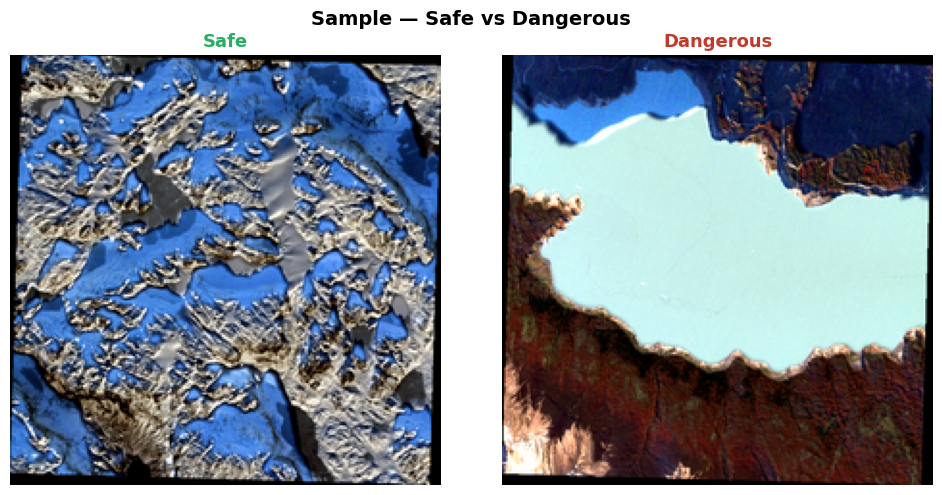

✅ Sample images saved!


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# STEP 1: Convert TIF → PNG
# ═══════════════════════════════════════════════════════════════════

def convert_tif_to_png(tif_path: str,
                        png_path: str) -> tuple:
    """
    Convert Sentinel-2 GeoTIFF to 224x224 PNG.
    Uses 2nd-98th percentile stretching.
    """
    try:
        with rasterio.open(tif_path) as src:
            if src.count < 3:
                return False, "Less than 3 bands"

            r = src.read(1).astype(np.float32)
            g = src.read(2).astype(np.float32)
            b = src.read(3).astype(np.float32)

            if np.all(r == 0) and np.all(g == 0):
                return False, "Empty image"

            r = np.nan_to_num(r, nan=0.0)
            g = np.nan_to_num(g, nan=0.0)
            b = np.nan_to_num(b, nan=0.0)

            def stretch(band):
                valid = band[band > 0]
                if len(valid) == 0:
                    return np.zeros_like(
                        band, dtype=np.uint8)
                p2  = np.percentile(valid, 2)
                p98 = np.percentile(valid, 98)
                if p98 <= p2: p98 = p2 + 1
                band = np.clip(band, p2, p98)
                return ((band - p2) /
                        (p98 - p2) * 255
                        ).astype(np.uint8)

            rgb = np.stack([stretch(r),
                            stretch(g),
                            stretch(b)], axis=2)
            img = Image.fromarray(rgb, 'RGB')
            img = img.resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                Image.LANCZOS)
            os.makedirs(
                os.path.dirname(png_path),
                exist_ok=True)
            img.save(png_path, format='PNG')
            return True, "OK"

    except Exception as e:
        return False, str(e)


print("🔄 Converting TIF → PNG\n")
print(f"  Output: {PNG_DIR}")
print(f"  ✅ Saved to Drive — safe to re-run!\n")

total_success = 0
total_failed  = 0

for cls in CLASS_NAMES:
    src_dir = CLASS_FOLDERS[cls]
    png_dir = f"{PNG_DIR}/{cls}"
    loc_dir = f"/content/local_tif/{cls}"
    os.makedirs(loc_dir, exist_ok=True)
    os.makedirs(png_dir, exist_ok=True)

    tif_files = [f for f in os.listdir(src_dir)
                 if f.lower().endswith('.tif')]

    todo, skipped = [], 0
    for f in tif_files:
        png_name = f.lower().replace('.tif', '.png')
        if os.path.exists(f"{png_dir}/{png_name}"):
            skipped += 1
        else:
            todo.append(f)

    print(f"  {cls}: {len(tif_files)} total | "
          f"{skipped} done | "
          f"{len(todo)} to convert")

    if not todo:
        total_success += skipped
        print(f"  ✅ All done!\n")
        continue

    print(f"    📦 Copying locally...", end=" ")
    for f in todo:
        src = f"{src_dir}/{f}"
        dst = f"{loc_dir}/{f}"
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
    print("done!")

    jobs = [
        (f"{loc_dir}/{f}",
         f"{png_dir}/{f.lower().replace('.tif','.png')}")
        for f in todo
    ]

    success = skipped
    failed  = 0

    with ThreadPoolExecutor(max_workers=4) as ex:
        futures = {
            ex.submit(convert_tif_to_png, t, p): f
            for (t, p), f in zip(jobs, todo)
        }
        with tqdm(total=len(jobs),
                  desc=f"    {cls}",
                  colour='green') as pbar:
            for future in as_completed(futures):
                ok, _ = future.result()
                if ok: success += 1
                else:  failed  += 1
                pbar.update(1)

    shutil.rmtree(loc_dir, ignore_errors=True)
    total_success += success
    total_failed  += failed
    print(f"    ✅ {success} converted | "
          f"{failed} failed\n")

print("=" * 50)
print(f"  ✅ CONVERSION COMPLETE")
print(f"  Total PNG: {total_success}")
print(f"  Failed:    {total_failed}")
print("=" * 50)

# Show sample images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Sample — Safe vs Dangerous",
             fontsize=14, fontweight='bold')
for ax, cls in zip(axes, CLASS_NAMES):
    folder = f"{PNG_DIR}/{cls}"
    files  = [f for f in os.listdir(folder)
              if f.endswith('.png')]
    if files:
        img   = Image.open(
            f"{folder}/{random.choice(files)}")
        color = '#27ae60' if cls=='Safe' else '#c0392b'
        ax.imshow(img)
        ax.set_title(cls, fontweight='bold',
                     color=color, fontsize=13)
        ax.axis('off')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_images.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images saved!")